# COGS 108 - EDA Checkpoint

## Authors

- Nathan Nguyen: Background research, Conceptualization, Project administration, Writing - original draft
- Sheilyne Munguia-Herrera: Background research, Writing and Editing 
- Riti Nalumachu: Writing, Editing, Data Curation
- Amjad Muhamad Afandy: Data curation, Writing - original draft

# Research Question

What demographic, legal, and geographic factors are associated with death row outcomes (execution, commutation, exoneration, or death from other causes) among individuals sentenced to death in the United States since 1976?
-  Predictive variables of interest include: race, gender, age at sentencing, state, county, and sentencing year.
- Factors that will be controlled for are: sentencing year and state.
- Appeal-level information is not available in the dataset.

## Background and Prior Work

Our interest in research is on what factors are associated with death row outcomes among individuals sentenced to death in the United States since 1976, including demographics, legal factors, and geographic distribution. The death penalty in the United States remains one of the most researched topics of the criminal justice system, with outcomes on death row shaped by more than just legal facts. Since its reestablishment in 1976, thousands of individuals have been sentenced to death, executed, exonerated, had sentences commuted, or died from other causes while on death row<sup><a name="ref3"></a>3</sup>. National data from *Death Row U.S.A.* indicate that death row populations are disproportionately male (98.9 %) and primarily White or Black, with significant variation across states, suggesting the importance of geographic context in analyzing death row outcomes<sup><a name="ref3"></a>3</sup>.

Research on specific jurisdictions has studied how demographic factors, particularly race and ethnicity, influence outcomes after a death sentence. Petrie and Coverdill researched Texas death row cases from 1974 to 2009 and found that the race of both offenders and victims affected the likelihood of execution, while having less impact on sentence relief such as commutation or overturning<sup><a name="ref5"></a>5</sup>. These findings suggest that while executions may reflect demographic disparities, other outcomes are shaped by different factors, including appeals processes and legal context.

The results in studies of high-activity death penalty counties show how race interacts with legal processes. Scott Phillips’ analysis of Harris County, Texas, shows that both defendant and victim race influenced whether a defendant was charged with capital murder and ultimately given the death penalty<sup><a name="ref4"></a>4</sup>. Combined with national data, these studies indicate that death row outcomes arise from the intersection of individual characteristics, legal decision-making, and geographic variation. Understanding these factors is important when addressing questions about individual justice and disparities in the administration of capital punishment.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Furman v. Georgia. *Oyez*. https://www.oyez.org/cases/1971/69-5030
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Gregg v. Georgia. *Oyez* https://www.oyez.org/cases/1975/74-6257
3. <a name="cite_note3"></a> [^](#cite_ref-3)Death Row U.S.A., Spring 2022 (As of April 1, 2022), Legal Defense Fund. https://heinonline.org/HOL/P?h=hein.journals/dprep8&i=1091
4. <a name="cite_note-4"></a> [^](#cite_ref-4)Michelle A. Petrie & James E. Coverdill, *Who Lives and Dies on Death Row? Race, Ethnicity, and Post‑Sentence Outcomes in Texas*. Social Problems, 57(4), 630–652. https://doi.org/10.1525/sp.2010.57.4.630

# Hypothesis


We hypothesize that death row outcomes differ based on demographic and sentence-related factors, such as the individuals' year sentenced, the U.S. state in which the were sentenced, and race. We specifically believe that some states and ethnic groups will have higher rates of execution or exoneration than others, with the rate of total executions decreasing over time. This hypothesis is based on prior research that shows long-standing racial and geographical disparities in how the death penalty is applied.

## Data

### Data Overview — The Condemned: Death Sentences in the Modern Era (1976–2019)

- Dataset Name: The Condemned  
- Link to the dataset: https://raw.githubusercontent.com/theintercept/the-condemned-data/refs/heads/master/the-condemed-data.csv  
- Number of observations: 7,335  
- Number of variables: 21  

This dataset, compiled by *The Intercept*, includes all known individuals sentenced to death in active U.S. death penalty jurisdictions from July 2, 1976 (the date of *Gregg v. Georgia*, which reinstated the modern era of capital punishment) through November 30, 2019. Each row represents one individual sentenced to death during the modern death penalty era.

As of 2019:
- 1,448 individuals were executed  
- 2,752 remain on death row  
- 3,135 were removed from death row for reasons other than execution (such as commutations, exonerations, resentencing, death in custody, or release)

This dataset allows us to examine how demographic, geographic, and temporal factors are associated with different death row outcomes across jurisdictions in the modern U.S. death penalty system.

### Variables most relevant to this project

Outcome variables
- executed: Indicates whether the individual was executed.
- volunteer_execution: Indicates whether the individual waived appeals and voluntarily accepted execution.
- commuted: Indicates whether the death sentence was commuted through executive action.
- exonerated: Indicates whether the individual was legally cleared of the charges.
- resentenced: Indicates whether the individual received a non-death sentence after review.
- released: Indicates whether the individual was released from prison.
- died / suicide: Indicates whether the individual died (including suicide) while on death row.
- currently_on_death_row: Indicates whether the individual remained on death row at the time of the dataset’s most recent update.

Demographic variables
- race: Recorded race of the individual, used to examine potential racial disparities in death row outcomes.
- gender: Recorded gender of the individual.
- DOB (date of birth): Used to calculate age at the time of sentencing.

Geographic variables
- state: The U.S. state where the individual was sentenced to death, allowing comparison across jurisdictions.
- county: The county of sentencing, reflecting the local legal and judicial context.

Additional variables
- sentencing_year: The year the death sentence was issued, allowing analysis of trends in capital punishment practices over time.
- current_sentence: Describes the individual’s current legal status after removal from death row or continued incarceration. Possible values include DR (Death Row), LWOP (Life Without Parole), LPP (Life With Possibility of Parole), Y (Term of Years), M (Term of Months), and TIME (Time Served).

### Dataset limitations relevant to this project

1. The dataset only includes individuals who received a death sentence. It does not include people charged with capital crimes who did not receive the death penalty, so disparities in who receives a death sentence cannot be analyzed.

2. The data were compiled from corrections departments, public defenders, advocacy groups, and independent trackers. Reporting standards may vary across states and may introduce inconsistencies.

3. Individuals sentenced earlier have had more time for appeals, commutations, or execution, so recent sentences may appear more often as “currently on death row.”

4. The dataset does not include detailed information about appeals, crime type, victim characteristics, or offense severity, which are important legal factors that may influence sentencing outcomes.

5. The dataset also lacks specific dates for executions, commutations, or exonerations, making it difficult to measure time spent on death row or analyze how quickly different outcomes occur.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data
import pandas as pd
import numpy as np

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
#datafiles = [
#    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
#]

#get_data.get_raw(datafiles,destination_directory='data/00-raw/')

In [3]:
# Load the dataset
file_path = "data/00-raw/the-condemed-data.csv"
df = pd.read_csv(file_path)

In [4]:
# Dataset details
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (7335, 21)

Column names:
['Status', 'state', 'sentencing_date', 'sentencing_year', 'full_name', 'last_name', 'first_name', 'race', 'County', 'DOB', 'gender', 'currently_on_death_row', 'executed', 'volunteer_execution', 'died', 'suicide', 'commuted', 'exonerated', 'resentenced', 'current_sentence', 'released']

Data types:
Status                     object
state                      object
sentencing_date            object
sentencing_year           float64
full_name                  object
last_name                  object
first_name                 object
race                       object
County                     object
DOB                        object
gender                     object
currently_on_death_row     object
executed                   object
volunteer_execution        object
died                       object
suicide                    object
commuted                   object
exonerated                 object
resentenced                object
current_sen

### Key Variables

| Variable | Type | Units / Format | Why It Matters |
|-----------|------|----------------|----------------|
| `first_name` | Text | String | Name component (can support matching/validation, but not unique). |
| `last_name` | Text | String | Name component (can support matching/validation, but not unique). |
| `status` | Categorical | Text label (e.g., "Currently on Death Row", "Executed") | High-level case status that summarizes the individual’s current legal situation and can be cross-validated with binary outcome indicators. |
| `race` | Categorical | Race classification | Used to examine racial disparities in death row outcomes. |
| `gender` | Categorical | Male / Female | Demographic characteristic. |
| `dob` | Date | YYYY-MM-DD (after parsing) | Used to calculate age at sentencing and analyze demographic patterns. |
| `sentencing_date` | Date | Mixed formats (full date, month/year, or year-only) | Used to analyze temporal trends; may require cleaning due to inconsistent formatting. |
| `sentencing_year` | Numeric | Year (e.g., 1977) | Clean and consistent time variable used for trend analysis. |
| `state` | Categorical | U.S. state (2-letter code) | Captures geographic variation in sentencing and outcomes. |
| `current_sentence` | Categorical | DR, LWOP, LPP, Y, M, TIME, etc. | Primary detailed outcome variable used to categorize death row outcomes. |


**Key for `current_sentence`:**
- **DR** – Currently on Death Row  
- **LWOP** – Life Without Parole  
- **LPP** – Life With Possibility of Parole  
- **Y** – Term of Years  
- **M** – Term of Months  
- **TIME** – Time Served  
- Additional categories indicate execution, exoneration, resentencing, or death in custody  

The `current_sentence` field serves as the main outcome variable and will be grouped into broader categories (executed, still on death row, sentence reduced, exonerated, died, etc.) for analysis.

---

In [5]:
# Preview first few rows
df.head()

,Status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,County,DOB,...,currently_on_death_row,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released
0,Not Currently on Death Row,AL,08/17/1976,1976.0,Donald Thigpen,Thigpen,Donald,Black,Escambia,1952,...,N,N,NaN,NaN,NaN,NaN,NaN,Y,LPP,NaN
1,Not Currently on Death Row,AL,11/22/1976,1976.0,Jerry Wayne Jacobs,Jacobs,Jerry,White,Blount,1949,...,N,N,NaN,NaN,NaN,NaN,NaN,Y,LWOP,NaN
2,Not Currently on Death Row,AL,11/22/1976,1976.0,John Lewis Jacobs,Jacobs,John,White,Blount,NaN,...,N,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Not Currently on Death Row,AL,1977,1977.0,James Willie Cochran,Cochran,James,Black,Jefferson,1943,...,N,N,NaN,NaN,NaN,NaN,Y,Y,DR,Y
4,Not Currently on Death Row,AL,1977,1977.0,Tommy Lewis,Lewis,Tommy,Black,Coffee,1951,...,N,N,NaN,NaN,NaN,NaN,NaN,Y,LWOP,NaN


In [6]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Updated column names:")
print(df.columns.tolist())


# Convert date columns to datetime
df['sentencing_date'] = pd.to_datetime(df['sentencing_date'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')


# Convert binary indicator columns to boolean
binary_cols = [
    'currently_on_death_row',
    'executed',
    'volunteer_execution',
    'died',
    'suicide',
    'commuted',
    'exonerated',
    'resentenced',
    'released'
]

for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.lower().map({
        'true': True,
        'false': False,
        '1': True,
        '0': False,
        'yes': True,
        'no': False,
        'y': True,
        'n': False
    })

print("\nUpdated data types:")
print(df.dtypes)


# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())


# Verify one row per individual
print("\nUnique individuals:", df['full_name'].nunique())
print("Total rows:", len(df))


Updated column names:
['status', 'state', 'sentencing_date', 'sentencing_year', 'full_name', 'last_name', 'first_name', 'race', 'county', 'dob', 'gender', 'currently_on_death_row', 'executed', 'volunteer_execution', 'died', 'suicide', 'commuted', 'exonerated', 'resentenced', 'current_sentence', 'released']

Updated data types:
status                            object
state                             object
sentencing_date           datetime64[ns]
sentencing_year                  float64
full_name                         object
last_name                         object
first_name                        object
race                              object
county                            object
dob                       datetime64[ns]
gender                            object
currently_on_death_row            object
executed                          object
volunteer_execution               object
died                              object
suicide                           object
commuted       

First, column names were standardized by removing extra spaces, converting all names to lowercase, and replacing spaces with underscores. This ensures consistent referencing throughout the analysis.

Next, the `sentencing_date` and `dob` columns were converted to datetime format to allow proper time-based calculations and trend analysis.

Binary indicator columns (such as `executed`, `commuted`, `exonerated`, etc.) were converted to boolean values (True/False). This ensures consistent formatting and allows for accurate logical comparisons and summary statistics.

The dataset was then checked for duplicate rows to confirm that no records were repeated.

Finally, the number of unique individuals (based on `full_name`) was compared to the total number of rows to verify that each row represents a distinct case.


In [7]:
# Find duplicated names
duplicate_names = df[df.duplicated('full_name', keep=False)].sort_values('full_name')

duplicate_names[['full_name', 'state', 'sentencing_date', 'current_sentence']].head(10)


,full_name,state,sentencing_date,current_sentence
7327,Alfredo Prieto,VA,NaT,NaN
1279,Alfredo Prieto,CA,1992-06-16,NaN
4517,Alton Coleman,OH,1985-05-06,NaN
3187,Alton Coleman,IN,1986-04-12,NaN
6090,Charles Evans,TX,1979-04-18,LPP
3191,Charles Evans,IN,1986-09-19,180Y
1869,Darnell Williams,CA,2016-09-21,NaN
3194,Darnell Williams,IN,1987-03-23,LWOP
3556,David Brown,LA,2018-06-22,NaN
3551,David Brown,LA,2011-10-29,NaN


We checked for duplicated values in the `full_name` column to determine whether any individuals appear more than once in the dataset. While some names appear multiple times, these records differ by state and/or sentencing date.

This indicates that these are different individuals who happen to share the same name, rather than duplicate records of the same person. Therefore, `full_name` is not a unique identifier, but each row still represents a distinct case.


In [8]:
# Missing values count
missing_counts = df.isna().sum().sort_values(ascending=False)

# Missing percentage
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

missing_summary


,Missing Count,Missing %
commuted,7267,99.072938
suicide,7232,98.595774
exonerated,7203,98.200409
volunteer_execution,7203,98.200409
released,7002,95.460123
died,6743,91.929107
dob,5911,80.586230
resentenced,4963,67.661895
current_sentence,4938,67.321063
sentencing_date,574,7.825494


### Missing Data Interpretation

Most missingness in this dataset occurs in binary event indicator columns such as `commuted`, `suicide`, `exonerated`, `volunteer_execution`, `released`, and `died`. These columns have very high percentages of missing values (over 90%). This is expected and not a data quality issue. These variables only contain values when the event occurred, so missing values generally mean the event did not happen.

The `dob` column has about 80% missing values. However, missingness does not appear to differ meaningfully between executed and non-executed individuals, suggesting it is not strongly related to outcome. This likely reflects inconsistent historical reporting rather than systematic bias. Because of this, age-based analysis may be limited.

Core analytic variables such as `state`, `race`, `status`, `sentencing_year`, `gender`, and `executed` have almost no missing values. These are the primary variables used in our analysis, and their completeness supports reliable outcome and demographic comparisons.

Overall, missingness is largely structural (due to event-based columns) and does not significantly compromise the main analyses of demographic and geographic patterns in death row outcomes.


In [9]:
# Sentencing date before 1976 (should not happen)
df[df['sentencing_date'].dt.year < 1976]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,currently_on_death_row,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released


In [10]:
# Future sentencing dates (should not happen)
df[df['sentencing_date'] > pd.Timestamp.today()]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,currently_on_death_row,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released


In [11]:
# Unrealistic situation 1
df[(df['executed'] == True) & (df['currently_on_death_row'] == True)]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,currently_on_death_row,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released


In [12]:
# Unrealistic situation 2
df[(df['exonerated'] == True) & (df['executed'] == True)]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,currently_on_death_row,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released


We checked for unrealistic or logically impossible entries in the dataset.

First, we verified that no sentencing dates occurred before 1976 (the beginning of the modern death penalty era) and that there were no future sentencing dates. Both checks returned zero rows, indicating no temporal inconsistencies.

Next, we checked for logical contradictions in outcome variables. Specifically, we confirmed that no individual was marked as both executed and currently on death row, and that no one was marked as both executed and exonerated. These checks also returned zero rows.

Overall, no obvious outliers or contradictory records were detected, suggesting that the dataset is internally consistent.


In [13]:
df['age_at_sentencing'] = (
    df['sentencing_date'].dt.year - df['dob'].dt.year
)

df['age_at_sentencing'].describe()


count    1256.000000
mean       31.112261
std         9.829185
min       -17.000000
25%        24.000000
50%        29.000000
75%        36.000000
max        77.000000
Name: age_at_sentencing, dtype: float64

In [14]:
# Unrealistic ages (under 15 or over 90)
suspicious_age = df[(df['age_at_sentencing'] < 15) | 
                    (df['age_at_sentencing'] > 90)]

suspicious_age[['full_name', 'state', 'age_at_sentencing']].head()


,full_name,state,age_at_sentencing
1440,Karl Darnell Holmes,CA,-17.0
4866,Benjamin Brewer,OK,10.0


In [15]:
# Remove clearly impossible ages only if they exist
df = df[~((df['age_at_sentencing'] < 15) | 
          (df['age_at_sentencing'] > 90))]

print("Shape after removing impossible ages:", df.shape)


Shape after removing impossible ages: (7333, 22)


We calculated age at sentencing by subtracting the birth year from the sentencing year. We then checked for unrealistic ages, specifically individuals under 15 years old or over 90 years old at the time of sentencing.

Two suspicious cases were identified, including one negative age and one age of 10, which are clearly impossible. These records were removed to maintain data accuracy.

After removing these unrealistic values, the dataset contained 7,333 observations.

Summary statistics show that among valid cases (1,256 individuals with available age data), the average age at sentencing was approximately 31 years old.

Overall, age values appear reasonable after cleaning, although many observations are missing age information.


In [16]:
df = df.dropna(how='all')

We checked for duplicated values in the `full_name` column to determine whether any individuals appear more than once in the dataset. While some names appear multiple times, these records differ by state and/or sentencing date.

This indicates that these are different individuals who happen to share the same name, rather than duplicate records of the same person. Therefore, `full_name` is not a unique identifier, but each row still represents a distinct case.


In [17]:
# Missing values count
missing_counts = df.isna().sum().sort_values(ascending=False)

# Missing percentage
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

missing_summary


,Missing Count,Missing %
commuted,7265,99.072685
suicide,7230,98.595391
volunteer_execution,7201,98.199918
exonerated,7201,98.199918
released,7000,95.458884
died,6741,91.926906
age_at_sentencing,6079,82.899223
dob,5911,80.608209
resentenced,4961,67.653075
current_sentence,4936,67.312151


### Missing Data Interpretation

Most missingness in this dataset occurs in binary event indicator columns such as `commuted`, `suicide`, `exonerated`, `volunteer_execution`, `released`, and `died`. These columns have very high percentages of missing values (over 90%). This is expected and not a data quality issue. These variables only contain values when the event occurred, so missing values generally mean the event did not happen.

The `dob` column has about 80% missing values. However, missingness does not appear to differ meaningfully between executed and non-executed individuals, suggesting it is not strongly related to outcome. This likely reflects inconsistent historical reporting rather than systematic bias. Because of this, age-based analysis may be limited.

Core analytic variables such as `state`, `race`, `status`, `sentencing_year`, `gender`, and `executed` have almost no missing values. These are the primary variables used in our analysis, and their completeness supports reliable outcome and demographic comparisons.

Overall, missingness is largely structural (due to event-based columns) and does not significantly compromise the main analyses of demographic and geographic patterns in death row outcomes.


In [18]:
# Sentencing date before 1976 (should not happen)
df[df['sentencing_date'].dt.year < 1976]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released,age_at_sentencing


In [19]:
# Future sentencing dates (should not happen)
df[df['sentencing_date'] > pd.Timestamp.today()]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released,age_at_sentencing


In [20]:
# Unrealistic situation 1
df[(df['executed'] == True) & (df['currently_on_death_row'] == True)]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released,age_at_sentencing


In [21]:
# Unrealistic situation 2
df[(df['exonerated'] == True) & (df['executed'] == True)]


,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released,age_at_sentencing


We checked for unrealistic or logically impossible entries in the dataset.

First, we verified that no sentencing dates occurred before 1976 (the beginning of the modern death penalty era) and that there were no future sentencing dates. Both checks returned zero rows, indicating no temporal inconsistencies.

Next, we checked for logical contradictions in outcome variables. Specifically, we confirmed that no individual was marked as both executed and currently on death row, and that no one was marked as both executed and exonerated. These checks also returned zero rows.

Overall, no obvious outliers or contradictory records were detected, suggesting that the dataset is internally consistent.


In [22]:
df['age_at_sentencing'] = (
    df['sentencing_date'].dt.year - df['dob'].dt.year
)

df['age_at_sentencing'].describe()


count    1254.000000
mean       31.167464
std         9.724244
min        15.000000
25%        24.000000
50%        29.000000
75%        36.000000
max        77.000000
Name: age_at_sentencing, dtype: float64

In [23]:
# Unrealistic ages (under 15 or over 90)
suspicious_age = df[(df['age_at_sentencing'] < 15) | 
                    (df['age_at_sentencing'] > 90)]

suspicious_age[['full_name', 'state', 'age_at_sentencing']].head()


,full_name,state,age_at_sentencing


In [24]:
# Remove clearly impossible ages only if they exist
df = df[~((df['age_at_sentencing'] < 15) | 
          (df['age_at_sentencing'] > 90))]

print("Shape after removing impossible ages:", df.shape)


Shape after removing impossible ages: (7333, 22)


We calculated age at sentencing by subtracting the birth year from the sentencing year. We then checked for unrealistic ages, specifically individuals under 15 years old or over 90 years old at the time of sentencing.

Two suspicious cases were identified, including one negative age and one age of 10, which are clearly impossible. These records were removed to maintain data accuracy.

After removing these unrealistic values, the dataset contained 7,333 observations.

Summary statistics show that among valid cases (1,256 individuals with available age data), the average age at sentencing was approximately 31 years old.

Overall, age values appear reasonable after cleaning, although many observations are missing age information.


In [25]:
df = df.dropna(how='all')

In [26]:
df.to_csv("data/02-processed/condemned_cleaned.csv", index=False)

In [27]:
file_path = "data/02-processed/condemned_cleaned.csv"
df_clean = pd.read_csv(file_path)

df_clean.head()

,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released,age_at_sentencing
0,Not Currently on Death Row,AL,1976-08-17,1976.0,Donald Thigpen,Thigpen,Donald,Black,Escambia,1952-01-01,...,False,NaN,NaN,NaN,NaN,NaN,True,LPP,NaN,24.0
1,Not Currently on Death Row,AL,1976-11-22,1976.0,Jerry Wayne Jacobs,Jacobs,Jerry,White,Blount,1949-01-01,...,False,NaN,NaN,NaN,NaN,NaN,True,LWOP,NaN,27.0
2,Not Currently on Death Row,AL,1976-11-22,1976.0,John Lewis Jacobs,Jacobs,John,White,Blount,NaN,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Not Currently on Death Row,AL,NaN,1977.0,James Willie Cochran,Cochran,James,Black,Jefferson,1943-01-01,...,False,NaN,NaN,NaN,NaN,True,True,DR,True,NaN
4,Not Currently on Death Row,AL,NaN,1977.0,Tommy Lewis,Lewis,Tommy,Black,Coffee,1951-01-01,...,False,NaN,NaN,NaN,NaN,NaN,True,LWOP,NaN,NaN


After completing all cleaning and validation steps, we removed any rows that were completely empty (if any existed). 

The cleaned dataset was then saved to `data/02-processed/condemned_cleaned.csv` to preserve a finalized version for analysis. 

Finally, we reloaded the saved file to confirm that it was written correctly. The cleaned dataset contains 7,333 observations and 22 variables, indicating that only clearly impossible age entries were removed.


## Results

### Exploratory Data Analysis

To better understand the dataset, we explore demographic patterns in death row sentencing. The goal of this exploratory analysis is to examine how factors such as race, gender, state, and sentencing year relate to death row outcomes including execution, commutation, exoneration, and resentencing. We first examine the distribution of outcomes in the dataset, followed by demographic patterns such as race and gender. These exploratory steps help identify potential disparities and trends that will guide further analysis.


In [28]:
file_path = "data/02-processed/condemned_cleaned.csv"
df = pd.read_csv(file_path)

# Preview first few rows
df.head()

,status,state,sentencing_date,sentencing_year,full_name,last_name,first_name,race,county,dob,...,executed,volunteer_execution,died,suicide,commuted,exonerated,resentenced,current_sentence,released,age_at_sentencing
0,Not Currently on Death Row,AL,1976-08-17,1976.0,Donald Thigpen,Thigpen,Donald,Black,Escambia,1952-01-01,...,False,NaN,NaN,NaN,NaN,NaN,True,LPP,NaN,24.0
1,Not Currently on Death Row,AL,1976-11-22,1976.0,Jerry Wayne Jacobs,Jacobs,Jerry,White,Blount,1949-01-01,...,False,NaN,NaN,NaN,NaN,NaN,True,LWOP,NaN,27.0
2,Not Currently on Death Row,AL,1976-11-22,1976.0,John Lewis Jacobs,Jacobs,John,White,Blount,NaN,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Not Currently on Death Row,AL,NaN,1977.0,James Willie Cochran,Cochran,James,Black,Jefferson,1943-01-01,...,False,NaN,NaN,NaN,NaN,True,True,DR,True,NaN
4,Not Currently on Death Row,AL,NaN,1977.0,Tommy Lewis,Lewis,Tommy,Black,Coffee,1951-01-01,...,False,NaN,NaN,NaN,NaN,NaN,True,LWOP,NaN,NaN


#### Distribution of Death Row Outcomes


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Executed'),
  Text(1, 0, 'Exonerated'),
  Text(2, 0, 'Commuted'),
  Text(3, 0, 'Resentenced'),
  Text(4, 0, 'Released'),
  Text(5, 0, 'Died')])

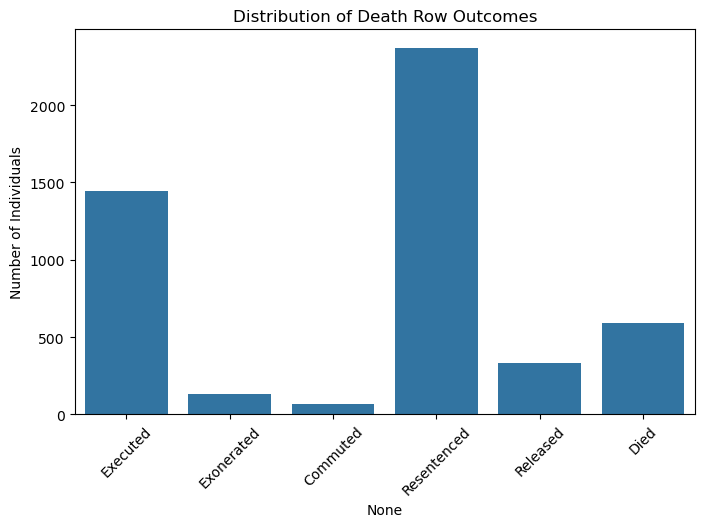

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

outcome_counts = {
    "Executed": df["executed"].sum(),
    "Exonerated": df["exonerated"].sum(),
    "Commuted": df["commuted"].sum(),
    "Resentenced": df["resentenced"].sum(),
    "Released": df["released"].sum(),
    "Died": df["died"].sum()
}

outcomes = pd.Series(outcome_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=outcomes.index, y=outcomes.values)
plt.title("Distribution of Death Row Outcomes")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)


This figure shows the distribution of outcomes for individuals who were sentenced to death in the dataset. Resentencing is the most common outcome, indicating that many individuals originally sentenced to death later received a different sentence. Executions represent the second largest outcome, followed by individuals who died while in custody and those who were released. In contrast, exonerations and commutations occur relatively rarely. Examining the overall distribution of outcomes provides important context for the analysis and helps establish a baseline before exploring how demographic, geographic, and temporal factors may be related to different death row outcomes.

### Death Row Outcomes by Race

This figure examines how death row outcomes are distributed across different racial groups. By comparing outcomes such as execution, resentencing, release, and exoneration across races, we can explore whether certain outcomes appear more common among specific groups. This helps identify potential demographic patterns in death row sentencing outcomes.

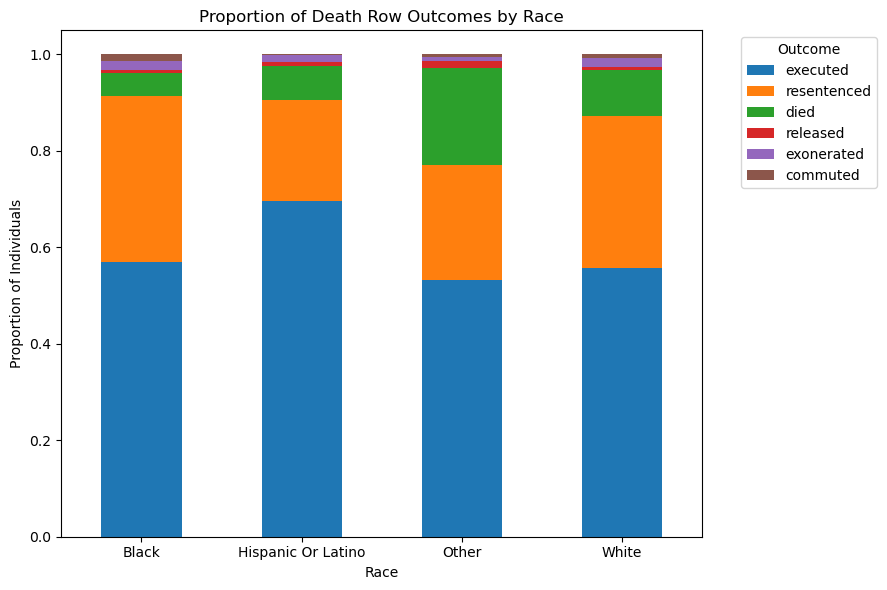

In [30]:
df['race_clean'] = df['race'].str.strip().str.title()

df['race_clean'] = df['race_clean'].replace({
    'Asian':'Other',
    'Native American':'Other',
    'Other Or Unknown':'Other'
})

outcome_cols = ['executed','exonerated','commuted','resentenced','released','died']

df['outcome'] = df[outcome_cols].fillna(0).idxmax(axis=1)

# Create race-outcome table
race_outcomes = df.groupby(['race_clean','outcome']).size().unstack().fillna(0)

# Convert counts to proportions
race_outcomes_prop = race_outcomes.div(race_outcomes.sum(axis=1), axis=0)

# Order outcomes for logical reading
outcome_order = ['executed','resentenced','died','released','exonerated','commuted']
race_outcomes_prop = race_outcomes_prop[outcome_order]

race_outcomes_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(9,6)
)

plt.title("Proportion of Death Row Outcomes by Race")
plt.xlabel("Race")
plt.ylabel("Proportion of Individuals")

plt.xticks(rotation=0)
plt.legend(title="Outcome", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

Across all racial groups, **execution is the most common outcome**, accounting for roughly half or more of the cases in each category. The **Hispanic or Latino group shows the highest proportion of executions**, at close to about 70% of cases. **Resentencing is the second most common outcome** across all groups, representing roughly 20–35% of cases depending on the race.

Smaller proportions of individuals **died while in custody**, which appears slightly higher in the **“Other” category** compared to the other groups. Outcomes such as **release, exoneration, and commutation occur very rarely**, making up only a small fraction of cases across all races. Overall, while execution and resentencing dominate the outcomes for every racial group, there are noticeable differences in the proportions of these outcomes across races. These patterns suggest potential demographic differences in how death row cases are resolved and provide motivation for further analysis of racial disparities in death row outcomes.

### Death Row Outcomes by Gender

This figure shows the proportion of death row outcomes within each gender group. Each bar represents the distribution of outcomes for individuals of that gender, allowing us to compare how cases are resolved across groups. Similar to the race analysis, execution and resentencing make up the largest share of outcomes. This visualization helps identify whether outcome patterns differ between genders and provides additional insight into demographic patterns in death row sentencing outcomes.

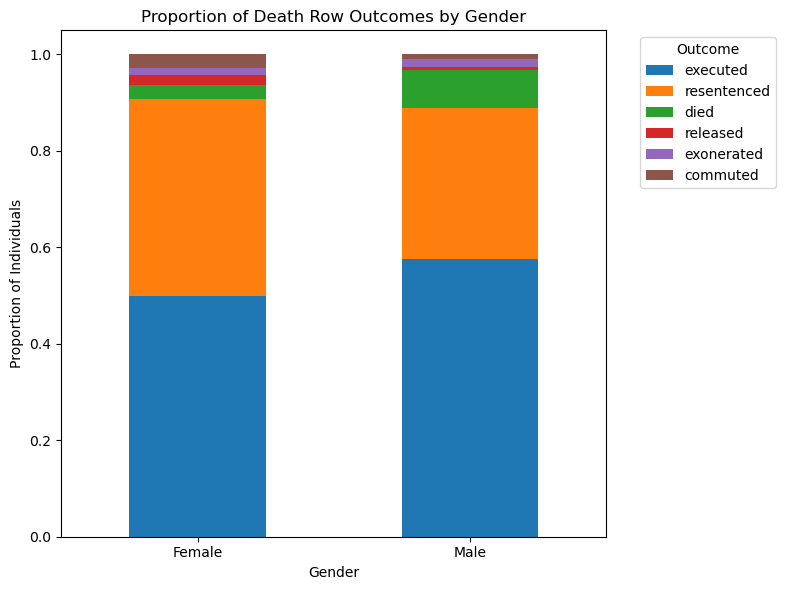

In [31]:
# Create gender-outcome table
gender_outcomes = df.groupby(['gender','outcome']).size().unstack().fillna(0)

# Convert to proportions
gender_outcomes_prop = gender_outcomes.div(gender_outcomes.sum(axis=1), axis=0)

# Order outcomes consistently with the race plot
gender_outcomes_prop = gender_outcomes_prop[outcome_order]


gender_outcomes_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Proportion of Death Row Outcomes by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion of Individuals")

plt.xticks(rotation=0)
plt.legend(title="Outcome", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

For both genders, **execution is the most common outcome**, accounting for roughly half of the cases for females and slightly more than half for males. **Resentencing** is the second largest outcome for both groups, making up a little over one-third of cases for males and closer to forty percent for females. Smaller proportions of individuals in each group **died while in custody**, while only a very small percentage were **released, exonerated, or had their sentences commuted**.

The overall distribution of outcomes is fairly similar between genders. However, males appear to have a **slightly higher proportion of executions**, while females show a **slightly higher proportion of resentencing**. Because the dataset contains many more male individuals than female individuals, these proportions allow for a clearer comparison of outcome patterns across genders. This analysis helps examine whether gender is associated with differences in how death row cases are ultimately resolved.

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Subjects did not affirmatively opt-in and have a clear understanding of the data uses because public records of incarcerated individuals were used. This includes state and federal departments of correction, state and federal public defenders, lawyers working for advocacy groups, and individuals who had been tracking this data in their respective states.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

 > The sources of the dataset may introduce inconsistencies in reporting practices across states and time periods. Some outcomes, such as deaths from natural causes or suicide, may also be underreported or classified differently depending on jurisdiction. To reduce the effect of these biases, we will focus our analysis on consistently recorded variables and frame results as associations instead of causal claims.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

 > Although the dataset has PII, such as names and dates of birth, our analysis will not use or display any identifiable variables. We will limit our analysis to demographic variables, sentencing information, and case outcomes.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

 > This dataset includes protected attributes such as race and gender, which allows us to test for disparities in death row outcomes across groups. Including these attributes examines inequalities and shows transparency in identifying potential bias in the criminal justice system.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

 > The data is publicly available on a GitHub repository, so it does not require any plan to protect and secure data. Since the data contains no private user submissions, there is no risk of unauthorized access or misuse.

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

 > We acknowledge that the dataset does not fully capture the social, legal, and systemic factors surrounding death row sentencing. This can be addressed by referencing relevant publications on criminal justice and capital punishment. With this, our analysis will reflect real-world context instead of relying on raw variables.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

 > We analyze distributions across race, gender, state, and time to identify patterns that may exhibit historical or institutional bias. These potential biases are acknowledged when interpreting results by avoiding overgeneralized findings.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

 > All visualizations, summary statistics, and reports will be designed to accurately reflect data. They will also use clear label, appropriate scales, and have explanations to avoid misleading interpretations. 

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

 > PII, such as names and dates of birth, will not be used, displayed, or analyzed. 

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

 >  The analysis will be documented in Jupyter notebooks on the group GitHub repo. This also makes it reproducible if we discover issues.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

 > In our case, demographic variables can be used as proxies for systemic biases in the criminal justice system. We are intentionally using these variables to study trends in death penalty outcomes. Our goal is to analyze patterns, instead of making individual predictions, so we will interpret results carefully to avoid unfair conclusions.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

 > We will compare outcomes across demographic groups to assess fairness in death row outcomes.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

 > Our metrics are the comparisons of death penalty outcomes across groups, such as the proportion of individuals executed versus exonerated. The size of each group will also be considered to avoid overinterpreting small samples.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 
 > Patterns and statistical results we find will be clearly explained if needed. 

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We will clearly describe the limitations of our analysis, showing what the dataset can and cannot tell us. This includes potential bias in data collection or missing variables.

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

 > Our findings could be misinterpreted or misused to justify discriminatory practices, so we clearly state state that our reuslts describe historical associations and do not support predictions about individuals.


## Team Expectations 

* *Communicate effectively via Instagram group chat.*
* *All members will contribute to the project equally.*
* *Any conflicts or issues will be communicated in a respectful manner.*
* *Deadlines should be respected and group members should be notified early of any delays.*
* *Possible required zoom or in person meetings to make sure everyone is making time to work on the project.*

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/16  | Async  | Import & Wrangle Data (Amjad); EDA (summary statistics, missing data checks) | Review and refine data cleaning; discuss EDA results; decide which variables will be included; plan specific visualizations (e.g., outcome distributions by state, race, and sentencing year)   |
| 2/23  | Async  | Finalize wrangling/EDA; Begin Analysis (TBD) | Discuss and edit analysis results; generate and interpret key plots; decide on statistical models; assess which predictors show strongest associations |
| 3/4  | Async  | Complete analysis; Draft results/conclusion/discussion (TBD)| Compare results across models; refine visualizations; interpret findings in relation to hypothesis and prior work; edit full project for clarity and coherence |
| 3/18  | Before 11:59 PM  | Finalize project and double checking | Turn in Final Project & Group Project Surveys |